In [1]:
%load_ext autoreload

import os, sys
import networkx as nx

sys.path.insert(0, "../")
sys.path.insert(0, "/home/j/joppich/.local/lib/python3.11/site-packages/")
#otherwise leidenalg is used in an outdated version ...

import leidenalg as la
print("la", la.version)

%autoreload 2
from PICASO.kgraph import *
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

from collections import defaultdict, Counter,namedtuple

import random
random.seed(42)

import pickle

la 0.10.2


/mnt/extproj/projekte/bartelt/software/miniconda3/envs/regnetworks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
kg = KGraph()
kg.load_kgraph("../data/initial_base_graph.out")

In [3]:
kg

KGraph KGraph with 111032 nodes and 1617389 edges

In [4]:
with open("myocardial_tlda.pickle", 'rb') as f:    
    tlda = pickle.load(f)

In [5]:
import copy
import csrgraph as cg
from tqdm import tqdm

%autoreload 2
class FrozenDict(dict):
    #https://stackoverflow.com/questions/2703599/what-would-a-frozen-dict-be
    
    def __init__(self, *args, **kwargs):
        self._hash = None
        super(FrozenDict, self).__init__(*args, **kwargs)

    def __hash__(self):
        if self._hash is None:
            self._hash = hash(tuple(sorted(self.items())))  # iteritems() on py2
        return self._hash

    def _immutable(self, *args, **kws):
        raise TypeError('cannot change object - object is immutable')

    # makes (deep)copy alot more efficient
    def __copy__(self):
        return self

    def __deepcopy__(self, memo=None):
        if memo is not None:
            memo[id(self)] = self
        return self

    __setitem__ = _immutable
    __delitem__ = _immutable
    pop = _immutable
    popitem = _immutable
    clear = _immutable
    update = _immutable
    setdefault = _immutable

In [6]:
%autoreload 2
class LRInteractomeClass:

    def __init__( self, interactome_file=None):

        self.interaction_df = pd.read_csv("https://raw.githubusercontent.com/soumelis-lab/ICELLNET/master/data/ICELLNETdb.tsv", sep="\t")

        self.allInteractions = self.read_interactions()
        self.sep = "_!!_"


    def read_interactions(self):
        ligandCols = [x for x in self.interaction_df.columns if "Ligand" in x]
        receptorCols = [x for x in self.interaction_df.columns if "Receptor" in x]
        
        familyCol = "Family"
        subfamilyCol = "Subfamily"

        allInteractions = defaultdict(set)
        
        for ri, row in self.interaction_df.iterrows():
        
            for l in ligandCols:
                for r in receptorCols:
        
                    lig = row[l]
                    rec = row[r]
        
                    if lig is None or rec is None:
                        continue
        
                    allInteractions[(lig, rec)].add( FrozenDict({"ligand": lig, "receptor": rec, "family": row[familyCol], "subfamily": row[subfamilyCol], "type": "lr_interaction", "score":0, "source":"LRInteractomeClass"}) )

        return allInteractions

    def _new_node_name(self, node, kg):

        if not isinstance(kg, str):
            return "{}{}{}".format(kg.kgraph_name, self.sep, node)
        else:
            return "{}{}{}".format(kg, self.sep, node)   

    def create_interactome_network(self, kg1, kg2):

        if kg1.kgraph_name is None or kg2.kgraph_name is None or not kg1.kgraph_name != kg2.kgraph_name:
            
            print("kg1 name must not be equal to kg2 name")
            raise ValueError("kg1 name must not be equal to kg2 name")

        ikg = KGraph(kgraph_name="interactome_{}_{}".format(kg1.kgraph_name, kg2.kgraph_name))

        ## copy over nodes
        for node in kg1.kg.nodes:
            nnode = self._new_node_name(node, kg1)
            ikg.kg.add_node(nnode, **kg1.kg.nodes[node])

        for node in kg2.kg.nodes:
            nnode = self._new_node_name(node, kg2)
            ikg.kg.add_node(nnode, **kg2.kg.nodes[node])

        ## copy over edges
        for edge in kg1.kg.edges:
            nu = self._new_node_name(edge[0], kg1)
            nv = self._new_node_name(edge[1], kg1)

            ikg.kg.add_edge(nu, nv, **kg1.kg.edges[edge])

        for edge in kg2.kg.edges:
            nu = self._new_node_name(edge[0], kg2)
            nv = self._new_node_name(edge[1], kg2)

            ikg.kg.add_edge(nu, nv, **kg2.kg.edges[edge])


        # create interactions
        for lig, rec in self.allInteractions:
            self.add_interaction(lig, rec, ikg, kg1.kgraph_name, kg2.kgraph_name)
            self.add_interaction(lig, rec, ikg, kg2.kgraph_name, kg1.kgraph_name)

        return ikg

    def add_interaction(self, lig, rec, ikg, kg1name, kg2name):
        #kg1 => kg2
        nl = self._new_node_name(lig, kg1name)
        nr = self._new_node_name(rec, kg2name)

        if nl in ikg.kg.nodes and nr in ikg.kg.nodes:
            interact = list(self.allInteractions[(lig, rec)])[0]
            #if lig == "TIMP1" and rec == "LRP1":
            #    print(interact)
            ikg.kg.add_edge(nl, nr, **copy.deepcopy(interact))


    def score_interactions(self, ikg, interaction_type="lr_interaction", node_score_accessor=lambda x: x.get("score", 0), score_function=lambda x,y: x*y):
        
        for edge in ikg.kg.edges:
            edgeData = ikg.kg.edges[edge]
            if edgeData.get("type", None) == interaction_type:

                srcScore = node_score_accessor(ikg.kg.nodes[edge[0]])
                tgtScore = node_score_accessor(ikg.kg.nodes[edge[1]])

                interactScore = score_function(srcScore, tgtScore)

                ikg.kg.edges[edge]["score"] = interactScore                


    def plot_interactions_score_histogram(self, ikg):

        score_accessor=lambda x: x.get("score", 0)        
        scoredict = ikg.get_edge_edge_scores_per_type(edge_types=["lr_interaction"])
        scores = scoredict.get("lr_interaction", [])
        
        fig, ax = plt.subplots(figsize=(8, 4))

        # plot the cumulative histogram
        n, bins, patches = ax.hist(scores, len(scores), density=True, histtype='step',
                                cumulative=True, label='Empirical Score Distribution')

        # tidy up the figure
        ax.grid(True)
        ax.legend(loc='right')
        ax.set_title('Cumulative Histogram of Edge Scores')
        ax.set_xlabel('Score')
        ax.set_ylabel('Likelihood of Score')

        plt.show()

    def get_interactions_scored(self, ikg):

        allrecords = []
        for edge in ikg.kg.edges:
            edgeData = ikg.kg.edges[edge]
            if edgeData.get("type", None) == "lr_interaction":
                #print(edge[0], edge[1], edgeData)

                kg1name, src = edge[0].split(self.sep)
                kg2name, tgt = edge[1].split(self.sep)
                
                allrecords.append(( kg1name, src, kg2name, tgt, edgeData.get("family", ""), edgeData.get("subfamily", ""), edgeData.get("score", 0)))

        df = pd.DataFrame.from_records(allrecords)
        df.columns = ["network1", "source", "network2", "target", "family", "subfamily", "score"]

        df["zscore"] = (df["score"] - df["score"].mean())/df["score"].std(ddof=0)

        return df

    def score_interactions_rw(self, ikg, interaction_type="lr_interaction", node_score_accessor=lambda x: x.get("score", 0), score_function=lambda x,y: x*y):

        print("Creating forward walk graph")
        rg = self.create_random_walk_graph(ikg.to_gene_kgraph())
        print("Creating reverse walk graph")
        rg_inv = self.create_random_walk_graph(ikg.to_gene_kgraph(), inversed=True)

        print("Determining Ligands and Receptors")
        allLigands = set()
        allReceptors = set()
        for edge in ikg.kg.edges:
            edgeData = ikg.kg.edges[edge]
            if edgeData.get("type", None) == "lr_interaction":
                allLigands.add(edge[0])
                allReceptors.add(edge[1])

        print("Num Ligands", len(allLigands))
        print("Num Receptors", len(allReceptors))

        print("Calculating ligand network")
        ligandGenes = {}
        for ligand in tqdm(allLigands):
            ligandUpstream = self.get_rw_targets(rg_inv, [ligand], num_rws=100).most_common(30)
            ligandGenes[ligand] = ligandUpstream

        print("Calculating receptor network")
        receptorGenes = {}
        for receptor in tqdm(allReceptors):
            receptorDownstream = self.get_rw_targets(rg, [receptor], num_rws=100).most_common(30)
            receptorGenes[receptor] = receptorDownstream


        print("Scoring interactions")
        allrecords = []
        for edge in tqdm(ikg.kg.edges):
            edgeData = ikg.kg.edges[edge]
            if edgeData.get("type", None) == interaction_type:
                #print(edge[0], edge[1], edgeData)

                ligandNodes = [x[0] for x in ligandGenes[edge[0]]]
                receptorNodes = [x[0] for x in receptorGenes[edge[1]]]

                ligandScore = self.score_nodes(ikg, ligandNodes)
                receptorScore = self.score_nodes(ikg, receptorNodes)

                interactScore = score_function(ligandScore, receptorScore)

                ikg.kg.edges[edge]["score"] = interactScore    

        return ligandGenes, receptorGenes

    def score_nodes(self, ikg, nodes):

        skg = ikg.subset_kg(nodes)
        escores = np.array(skg.get_edge_scores())

        escores = escores[~np.isnan(escores)]
        
        return np.mean(escores)

    def create_random_walk_graph( self, kg: KGraph, weight="score", inversed=False):
        if inversed:
            mat = nx.adjacency_matrix(kg.kg.reverse(), weight=weight)
        else:
            mat = nx.adjacency_matrix(kg.kg, weight=weight)
            
        mat.data = mat.data.astype(np.float32)
        mat = scipy.sparse.csr_matrix(mat)
        return cg.csrgraph(mat, nodenames=[x for x in kg.kg.nodes], copy=False)

    def get_rw_targets(self, rwg, nodes, num_rws=10, walk_length=15):
        downstreamTargets = Counter()
    
        for node in nodes:
            rws = rwg.random_walks( walklen=walk_length, epochs=num_rws, start_nodes=[rwg.names.to_list().index(x) for x in [node]] )
        
            for rw in rws:
                for node in rw:
                    downstreamTargets[rwg.names[node]] += 1
    
        for node in nodes:
            del downstreamTargets[node]
        
        return downstreamTargets
    
    def list_all_lr_interactions(self, ikg):

        for edge in ikg.kg.edges:
            edgeData = ikg.kg.edges[edge]
            if edgeData.get("type", None) == "lr_interaction":
                print(edge[0], edge[1], edgeData)
                

In [7]:
[x for x in tlda.cellgroupdata]

['Adipocyte',
 'Cardiomyocyte',
 'Cycling cells',
 'Endothelial',
 'Fibroblast',
 'Lymphoid',
 'Mast',
 'Myeloid',
 'Neuronal',
 'Pericyte',
 'vSMCs']

In [8]:
targets = ["Fibroblast", "vSMCs", "Endothelial"]
sources = ["Myeloid"]

In [9]:
[x for x in tlda.cellgroupdata["Myeloid"]["kg"]]

['Myeloid_RZ', 'Myeloid_BZ', 'Myeloid_IZ', 'Myeloid_FZ']

In [10]:
tlda.cellgroupdata["Myeloid"]["kg"]["Myeloid_FZ"]

KGraph KGraph_vs_KGraph with 171852 nodes and 2044325 edges

In [11]:
lrInt = LRInteractomeClass()

In [12]:
comparisons = dict()
comparisons_rw = dict()

lrNodeNetworks = defaultdict(lambda: dict())

for src in sources:

    for tgt in targets:

        srcName="{}_FZ".format(src)
        tgtName="{}_FZ".format(tgt)
        
        srcKG = tlda.cellgroupdata[src]["kg"][srcName]
        tgtKG = tlda.cellgroupdata[tgt]["kg"][tgtName]

        srcKG.kgraph_name = srcName
        tgtKG.kgraph_name = tgtName
        
        intkg = lrInt.create_interactome_network(srcKG, tgtKG)
        lrInt.score_interactions(intkg, node_score_accessor=lambda x: x.get("fc_score", 0), score_function=lambda x,y: x+y)

        sdf = lrInt.get_interactions_scored(intkg)
        print(sdf.head())

        comparisons[(srcName, tgtName)] = sdf

        lnodes, rnodes = lrInt.score_interactions_rw(intkg, node_score_accessor=lambda x: x.get("fc_score", 0), score_function=lambda x,y: x+y)

        lrNodeNetworks[(srcName, tgtName)]["Lnodes"] = lnodes
        lrNodeNetworks[(srcName, tgtName)]["Rnodes"] = rnodes
       
        sdfrw = lrInt.get_interactions_scored(intkg)
        print(sdfrw.head())
        
        comparisons_rw[(srcName, tgtName)] = sdfrw
        

     network1 source       network2   target         family subfamily  \
0  Myeloid_FZ   PSAP  Fibroblast_FZ    GPR37            NaN       NaN   
1  Myeloid_FZ   PSAP  Fibroblast_FZ  GPR37L1            NaN       NaN   
2  Myeloid_FZ   GZMB  Fibroblast_FZ    IGF2R  Growth factor       NaN   
3  Myeloid_FZ   IGF2  Fibroblast_FZ    IGF1R  Growth factor       NaN   
4  Myeloid_FZ   IGF2  Fibroblast_FZ    IGF2R  Growth factor       NaN   

      score    zscore  
0 -0.430320 -0.264395  
1 -0.757519 -0.620526  
2 -0.406446 -0.238410  
3  0.195795  0.417082  
4 -0.280346 -0.101159  
Creating forward walk graph
Creating reverse walk graph
Determining Ligands and Receptors
Num Ligands 1264
Num Receptors 938
Calculating ligand network


100%|██████████| 1264/1264 [00:17<00:00, 72.52it/s] 


Calculating receptor network


100%|██████████| 938/938 [00:09<00:00, 104.19it/s]


Scoring interactions


...

Calculating receptor network


100%|██████████| 938/938 [00:08<00:00, 105.61it/s]


Scoring interactions


/mnt/extproj/projekte/bartelt/software/miniconda3/envs/regnetworks/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/extproj/projekte/bartelt/software/miniconda3/envs/regnetworks/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 4092264/4092264 [00:33<00:00, 123830.43it/s]


     network1 source        network2   target         family subfamily  \
0  Myeloid_FZ   PSAP  Endothelial_FZ    GPR37            NaN       NaN   
1  Myeloid_FZ   PSAP  Endothelial_FZ  GPR37L1            NaN       NaN   
2  Myeloid_FZ   GZMB  Endothelial_FZ    IGF2R  Growth factor       NaN   
3  Myeloid_FZ   IGF2  Endothelial_FZ    IGF1R  Growth factor       NaN   
4  Myeloid_FZ   IGF2  Endothelial_FZ    IGF2R  Growth factor       NaN   

      score    zscore  
0  1.584302  0.285713  
1  1.276960 -0.610630  
2  1.534307  0.139907  
3  1.827249  0.994252  
4  1.600061  0.331674  


In [13]:
for x in comparisons:
    print(x)

('Myeloid_FZ', 'Fibroblast_FZ')
('Myeloid_FZ', 'vSMCs_FZ')
('Myeloid_FZ', 'Endothelial_FZ')


In [14]:
compDF = pd.concat([comparisons[x] for x in comparisons], axis=0).replace([np.inf, -np.inf], np.nan).dropna(axis=0)
rwcompDF = pd.concat([comparisons_rw[x] for x in comparisons_rw], axis=0).replace([np.inf, -np.inf], np.nan).dropna(axis=0)

In [15]:
compDF[compDF.network1 == "Myeloid_FZ"].sort_values("zscore")

,network1,source,network2,target,family,subfamily,score,zscore
1527,Myeloid_FZ,IL1F10,vSMCs_FZ,IL1RAPL2,Cytokine,IL1 family,-4.608175,-4.735779
95,Myeloid_FZ,CCL2,Endothelial_FZ,CCR2,Chemokine,CC,-3.253424,-3.663986
93,Myeloid_FZ,CCL2,Endothelial_FZ,ACKR1,Chemokine,CC,-3.204335,-3.604759
95,Myeloid_FZ,CCL2,vSMCs_FZ,CCR2,Chemokine,CC,-3.494236,-3.568820
94,Myeloid_FZ,CCL2,Endothelial_FZ,ACKR2,Chemokine,CC,-3.011137,-3.371659
...,...,...,...,...,...,...,...,...
433,Myeloid_FZ,COL5A2,Fibroblast_FZ,ITGA1,ECM interaction,COL,3.580381,4.100936
1600,Myeloid_FZ,COL8A1,Fibroblast_FZ,ITGA1,ECM interaction,COL,3.616758,4.140530
947,Myeloid_FZ,AREG,Endothelial_FZ,EGFR,Growth factor,EGFR family,3.260939,4.195777
432,Myeloid_FZ,COL5A2,Fibroblast_FZ,ITGA10,ECM interaction,COL,3.726854,4.260361


In [16]:
rwcompDF[rwcompDF.network1 == "Myeloid_FZ"].sort_values("zscore")

,network1,source,network2,target,family,subfamily,score,zscore
1785,Myeloid_FZ,NECTIN3,vSMCs_FZ,TIGIT,Checkpoint,Nectin,-2.113747,-8.812173
1785,Myeloid_FZ,NECTIN3,Endothelial_FZ,TIGIT,Checkpoint,Nectin,-0.960616,-7.136372
185,Myeloid_FZ,L1CAM,Endothelial_FZ,ERBB4,Growth factor,EGFR family,-0.123895,-4.696132
184,Myeloid_FZ,L1CAM,Endothelial_FZ,ERBB3,Growth factor,EGFR family,-0.105490,-4.642454
773,Myeloid_FZ,CCL25,Fibroblast_FZ,CCR9,Chemokine,CC,0.036599,-4.452812
...,...,...,...,...,...,...,...,...
439,Myeloid_FZ,COL11A1,vSMCs_FZ,ITGA1,ECM interaction,COL,2.615346,2.457429
487,Myeloid_FZ,TNFSF11,Fibroblast_FZ,TNFRSF11A,Cytokine,TNF,2.555958,2.522498
1428,Myeloid_FZ,CD70,vSMCs_FZ,CD27,Checkpoint,TNF,2.657261,2.557313
436,Myeloid_FZ,COL11A1,vSMCs_FZ,ITGA2,ECM interaction,COL,2.682850,2.618294


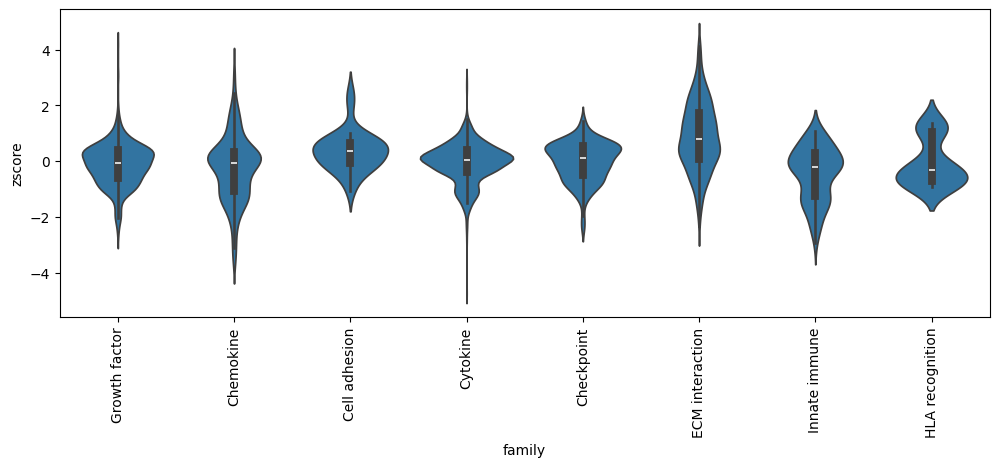

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.violinplot(compDF[compDF.network1 == "Myeloid_FZ"], x="family", y="zscore", ax=ax)
ax.tick_params(axis='x', rotation=90)

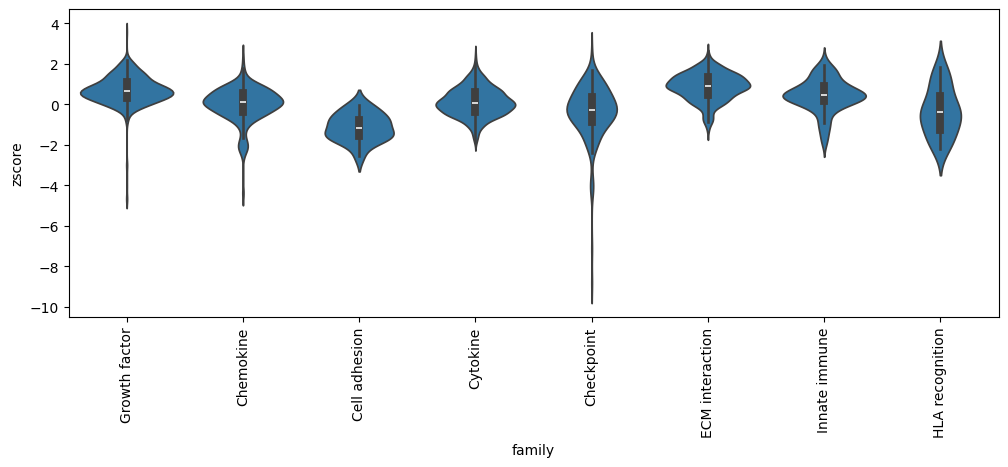

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.violinplot(rwcompDF[rwcompDF.network1 == "Myeloid_FZ"], x="family", y="zscore", ax=ax)
ax.tick_params(axis='x', rotation=90)

In [19]:
from statannot import add_stat_annotation
from scipy.stats import mannwhitneyu, normaltest
from statannotations.Annotator import Annotator

from natsort import natsorted

In [20]:

def boxen_plot_with_stats(indf, x, y, figsize=(8,6), **kwargs):
       
    order = natsorted(list(set(indf[x])))
    
    plotting_parameters = {
        'data':    indf,
        'x':       x,
        'y':       y,
        'order':   order
    }
    
    stat_results = []
    pairs = []
    for i in range(0, len(order)):

        for j in range(i+1, len(order)):

            test = mannwhitneyu(indf[indf[x]==order[i]][y], indf[indf[x]==order[j]][y], alternative="two-sided")
            if test.pvalue < 1e-20:
                pairs.append( (order[i], order[j]) )
                stat_results.append( test )
            
    pvalues = [x.pvalue for x in stat_results]
    formatted_pvalues = [f"p={p:.2e}" for p in pvalues]
    
    print(pairs)
    print(pvalues)
    
    # Plot with seaborn
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxenplot(data=indf, x=x, y=y, order=order, ax=ax, **kwargs)
    ax.tick_params(axis='x', rotation=90)
    ax.set(xlabel=x, ylabel=y)
    
    # Add annotations
    annotator = Annotator(ax, pairs, data=indf, x=x, y=y, order=order)
    #annotator.set_custom_annotations(formatted_pvalues)
    #annotator.set_pvalues(pvalues)
    annotator.configure(text_format="simple")
    annotator.set_pvalues_and_annotate(pvalues)

    #annotator.annotate()



[('Checkpoint', 'ECM interaction'), ('Chemokine', 'ECM interaction'), ('Cytokine', 'ECM interaction'), ('ECM interaction', 'Growth factor'), ('ECM interaction', 'Innate immune')]
[1.1914183435905835e-22, 2.4010944359023196e-41, 1.1305628478959405e-66, 1.3366615331314583e-58, 5.854501527592847e-23]
Cytokine vs. ECM interaction: Custom statistical test, P_val:1.131e-66
ECM interaction vs. Growth factor: Custom statistical test, P_val:1.337e-58
Chemokine vs. ECM interaction: Custom statistical test, P_val:2.401e-41
Checkpoint vs. ECM interaction: Custom statistical test, P_val:1.191e-22
ECM interaction vs. Innate immune: Custom statistical test, P_val:5.855e-23


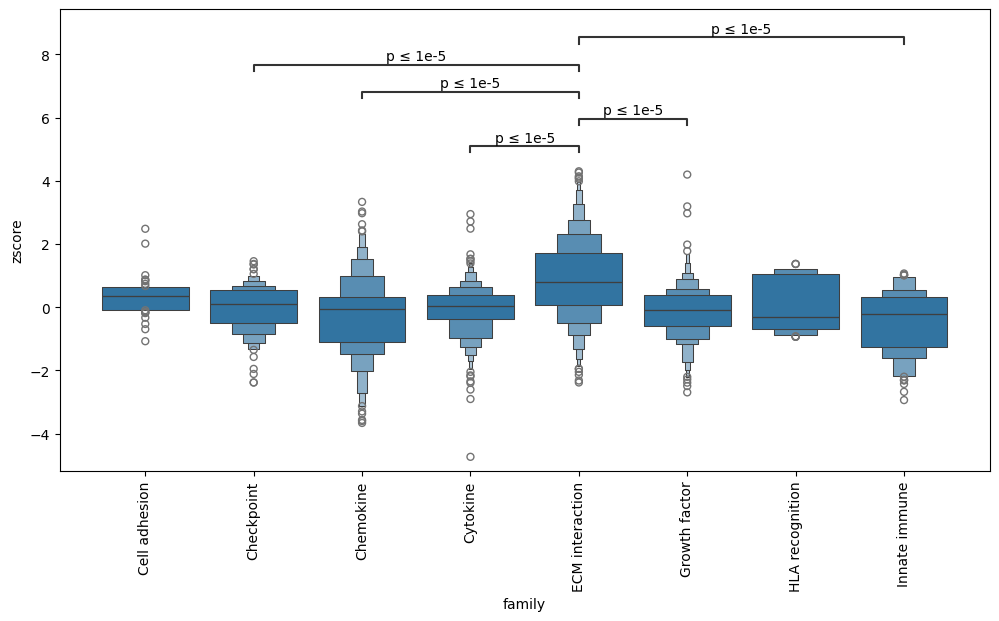

In [21]:
boxen_plot_with_stats(compDF[compDF.network1 == "Myeloid_FZ"], x="family", y="zscore", figsize=(12,6))

[('Chemokine', 'ECM interaction'), ('Chemokine', 'Growth factor'), ('Cytokine', 'ECM interaction'), ('Cytokine', 'Growth factor')]
[4.727455594804015e-32, 2.6800054481892575e-21, 1.9245629541258489e-38, 8.537368041861605e-22]
Cytokine vs. ECM interaction: Custom statistical test, P_val:1.925e-38
Chemokine vs. ECM interaction: Custom statistical test, P_val:4.727e-32
Cytokine vs. Growth factor: Custom statistical test, P_val:8.537e-22
Chemokine vs. Growth factor: Custom statistical test, P_val:2.680e-21


Text(0.5, 1.0, 'Myeloid ➡️ Fibroblast FZ')

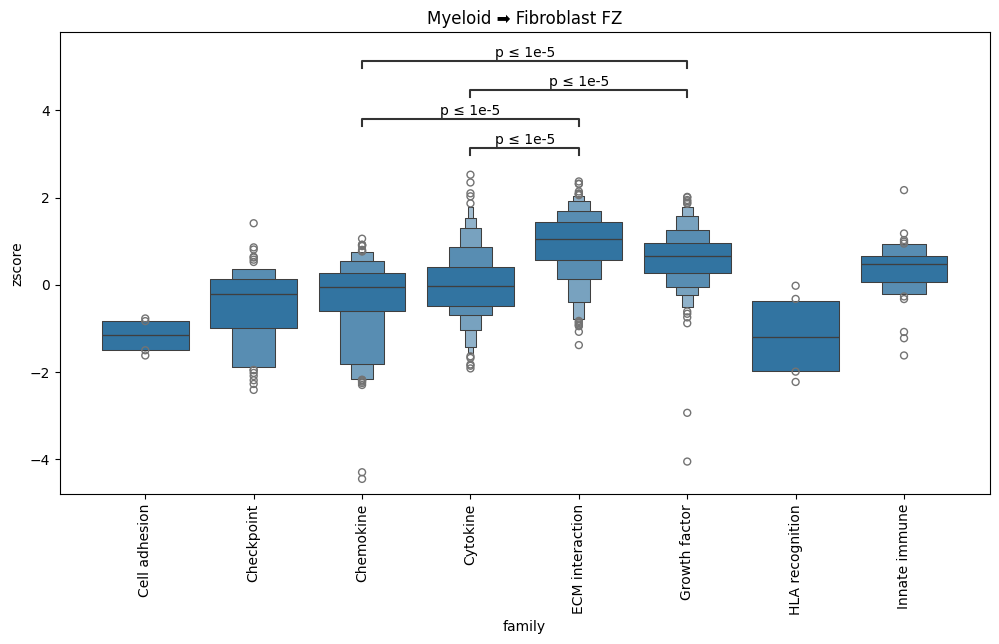

In [22]:
boxen_plot_with_stats(rwcompDF[(rwcompDF.network1 == "Myeloid_FZ") & (rwcompDF.network2 == "Fibroblast_FZ")], x="family", y="zscore", figsize=(12,6))
plt.title("Myeloid ➡️ Fibroblast FZ")

In [23]:
compDF.to_csv("interactions_myeloid_to_fibroblast_endo_vsmcs.tsv", sep="\t")
rwcompDF.to_csv("interactions_randomwalk_myeloid_to_fibroblast_endo_vsmcs.tsv", sep="\t")

In [24]:
[x for x in lrNodeNetworks]

[('Myeloid_FZ', 'Fibroblast_FZ'),
 ('Myeloid_FZ', 'vSMCs_FZ'),
 ('Myeloid_FZ', 'Endothelial_FZ')]

In [61]:
def enrich_genesets(mini_comms, fullkg, gstype="drug", isep="_!!_"):
   
    genes2drugs = defaultdict(set)
    
    for mcomm in tqdm(mini_comms):
        genes = set([x[0].split(isep)[1] for x in mini_comms[mcomm]] + [mcomm.split(isep)[1]])
        #print(mcomm, genes)

        for gene in genes:
            for _, onode in kg.kg.out_edges(gene):
                if kg.node_type_overlap(onode, [gstype]):
                    genes2drugs[gene].add(onode)

    allrecords = []
    for gene in tqdm(genes2drugs):

        for drug in genes2drugs[gene]:
            drugtargets = kg._get_predecessors(drug, ntype="gene", n=1)
            mcoverlap = set(drugtargets).intersection(genes2drugs)
            allrecords.append( (gene, drug, kg.kg.nodes[drug].get("name", drug), len(mcoverlap), len(drugtargets), len(mcoverlap)/len(drugtargets), tuple(mcoverlap) ) )
    
    df= pd.DataFrame.from_records(allrecords)
    df.columns = ["gene", "drugID", "drugName", "overlap", "drugtargets", "drugtargetfraction", "targets"]
    return df

In [64]:
lrdNodeNetworks = {}

for comp in lrNodeNetworks:

    ldf = enrich_genesets(lrNodeNetworks[comp]["Lnodes"], kg)
    rdf = enrich_genesets(lrNodeNetworks[comp]["Rnodes"], kg)

    lrdf = comparisons_rw[comp]

    fdf = lrdf.merge(ldf, how='left', left_on="source", right_on="gene").merge(rdf, how="left", left_on="target", right_on="gene", suffixes=["_ligand", "_receptor"])
    lrdNodeNetworks[comp] = fdf
    

100%|██████████| 394/394 [00:00<00:00, 4622.03it/s]


In [65]:
rwDrugDF = pd.concat([lrdNodeNetworks[x] for x in lrdNodeNetworks], axis=0)

In [66]:
rwDrugDF

,network1,source,network2,target,family,subfamily,score,zscore,gene_ligand,drugID_ligand,...,drugtargets_ligand,drugtargetfraction_ligand,targets_ligand,gene_receptor,drugID_receptor,drugName_receptor,overlap_receptor,drugtargets_receptor,drugtargetfraction_receptor,targets_receptor
0,Myeloid_FZ,PSAP,Fibroblast_FZ,GPR37,NaN,NaN,1.970909,0.902683,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Myeloid_FZ,PSAP,Fibroblast_FZ,GPR37L1,NaN,NaN,2.057903,1.143542,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Myeloid_FZ,GZMB,Fibroblast_FZ,IGF2R,Growth factor,NaN,1.352716,-0.808898,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Myeloid_FZ,IGF2,Fibroblast_FZ,IGF1R,Growth factor,NaN,2.021644,1.043152,IGF2,CHEMBL2109355,...,2.0,1.0,"(IGF2, IGF1)",IGF1R,CHEMBL1743019,FIGITUMUMAB,1.0,1.0,1.0,"(IGF1R,)"
4,Myeloid_FZ,IGF2,Fibroblast_FZ,IGF1R,Growth factor,NaN,2.021644,1.043152,IGF2,CHEMBL2109355,...,2.0,1.0,"(IGF2, IGF1)",IGF1R,CHEMBL2109356,BIIB-022,1.0,1.0,1.0,"(IGF1R,)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18003,Endothelial_FZ,ALKAL1,Myeloid_FZ,ALK,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,ALK,CHEMBL3545311,BRIGATINIB,2.0,2.0,1.0,"(EGFR, ALK)"
18004,Endothelial_FZ,ALKAL1,Myeloid_FZ,ALK,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,ALK,CHEMBL2403108,CERITINIB,1.0,1.0,1.0,"(ALK,)"
18005,Endothelial_FZ,ALKAL1,Myeloid_FZ,ALK,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,ALK,CHEMBL4113131,ENSARTINIB,1.0,1.0,1.0,"(ALK,)"
18006,Endothelial_FZ,ALKAL1,Myeloid_FZ,ALK,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,ALK,CHEMBL601719,CRIZOTINIB,2.0,2.0,1.0,"(MET, ALK)"


In [67]:
rwDrugDF.to_csv("interactions_randomwalk_with_drugs.tsv", index=False, sep="\t")

In [73]:
rwDrugDF.query("(drugtargetfraction_ligand > 0.8)").query("(drugtargets_ligand > 2)").sort_values(["zscore", "drugtargetfraction_ligand"], ascending=[False, True])

,network1,source,network2,target,family,subfamily,score,zscore,gene_ligand,drugID_ligand,...,drugtargets_ligand,drugtargetfraction_ligand,targets_ligand,gene_receptor,drugID_receptor,drugName_receptor,overlap_receptor,drugtargets_receptor,drugtargetfraction_receptor,targets_receptor
2684,Myeloid_FZ,COL11A1,vSMCs_FZ,ITGA2,ECM interaction,COL,2.682850,2.618294,COL11A1,CHEMBL2095222,...,38.0,0.815789,"(COL6A1, COL5A2, COL4A3, COL2A1, LAMA2, COL4A1...",ITGA2,CHEMBL1743086,VATELIZUMAB,1.0,1.0,1.0,"(ITGA2,)"
2683,Myeloid_FZ,COL11A1,vSMCs_FZ,ITGA2,ECM interaction,COL,2.682850,2.618294,COL11A1,CHEMBL2108709,...,25.0,1.000000,"(COL6A1, COL5A2, COL4A3, COL2A1, COL4A1, COL1A...",ITGA2,CHEMBL1743086,VATELIZUMAB,1.0,1.0,1.0,"(ITGA2,)"
2690,Myeloid_FZ,COL11A1,vSMCs_FZ,ITGA1,ECM interaction,COL,2.615346,2.457429,COL11A1,CHEMBL2095222,...,38.0,0.815789,"(COL6A1, COL5A2, COL4A3, COL2A1, LAMA2, COL4A1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2689,Myeloid_FZ,COL11A1,vSMCs_FZ,ITGA1,ECM interaction,COL,2.615346,2.457429,COL11A1,CHEMBL2108709,...,25.0,1.000000,"(COL6A1, COL5A2, COL4A3, COL2A1, COL4A1, COL1A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2732,Myeloid_FZ,COL1A1,vSMCs_FZ,ITGA2,ECM interaction,COL,2.562762,2.332119,COL1A1,CHEMBL2095222,...,38.0,0.815789,"(COL6A1, COL5A2, COL4A3, COL2A1, LAMA2, COL4A1...",ITGA2,CHEMBL1743086,VATELIZUMAB,1.0,1.0,1.0,"(ITGA2,)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15372,Endothelial_FZ,COL4A6,Myeloid_FZ,ADGRG6,ECM interaction,Adhesion GPCR,NaN,NaN,COL4A6,CHEMBL2108709,...,25.0,1.000000,"(COL6A1, COL5A2, COL4A3, COL2A1, COL4A1, COL1A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
15388,Endothelial_FZ,COL4A5,Myeloid_FZ,ADGRG6,ECM interaction,Adhesion GPCR,NaN,NaN,COL4A5,CHEMBL2108709,...,25.0,1.000000,"(COL6A1, COL5A2, COL4A3, COL2A1, COL4A1, COL1A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
15404,Endothelial_FZ,COL4A2,Myeloid_FZ,ADGRG6,ECM interaction,Adhesion GPCR,NaN,NaN,COL4A2,CHEMBL2108709,...,25.0,1.000000,"(COL6A1, COL5A2, COL4A3, COL2A1, COL4A1, COL1A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
15420,Endothelial_FZ,COL4A3,Myeloid_FZ,ADGRG6,ECM interaction,Adhesion GPCR,NaN,NaN,COL4A3,CHEMBL2108709,...,25.0,1.000000,"(COL6A1, COL5A2, COL4A3, COL2A1, COL4A1, COL1A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
